# ET-DHP vs PID · Boeing 747
### Nonlinear model · 500 seconds · unknown failure time

**Comparison:** holding heading ψ = 0° and roll φ = 0°. At **137 seconds**, the left outboard engine loses **50% of its own thrust**, equivalent to 12.5% of total thrust at an unchanged throttle command. Controllers receive state measurements without a failure notification.

🔵 **ET-DHP** uses nominal LQR initialization and event-triggered actor/critic learning. Its nominal model stays fixed throughout the flight.  
🟠 **PID** uses fixed gains fitted on the healthy aircraft.  
Both share identical surface limits and a common speed/altitude controller.

Figures are executed and embedded in the notebook. Plotting code is available in collapsed cells. All values and percentages are computed from raw trajectories without smoothing.

This overview retains the **original controller settings**. For the tuned configuration, total-error comparison, and step-response tests, see [the full notebook](example_etdhp_vs_pid_b747.ipynb).

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import HTML, Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats

%matplotlib inline
set_matplotlib_formats('retina')

repo = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'tensoraerospace').is_dir())
sys.path.insert(0, str(repo))
data_dir = repo / 'outputs' / 'b747-etdhp-vs-pid'
figure_dir = data_dir / 'presentation'
figure_dir.mkdir(parents=True, exist_ok=True)

# True: rerun six simulations; False: use validated CSV files.
RERUN_SIMULATION = False
required = ['healthy_etdhp', 'healthy_pid', 'healthy_etdhp_online_model',
            'fault_etdhp', 'fault_pid', 'fault_etdhp_online_model']
if RERUN_SIMULATION or not all((data_dir / f'{key}.csv').exists() for key in required) or not (data_dir / 'metrics.json').exists():
    import torch
    from example.reinforcement_learning.incremental_adp import example_etdhp_vs_pid_b747 as demo
    torch.set_num_threads(1)
    cfg = demo.Experiment()
    traces, report = demo.run_comparison(cfg, include_online_model=True)
    plt.close(demo.save_comparison(data_dir, cfg, traces, report))
else:
    report = json.loads((data_dir / 'metrics.json').read_text())
    traces = {key: np.loadtxt(data_dir / f'{key}.csv', delimiter=',', skiprows=1) for key in required}

column = {name: i for i, name in enumerate(report['trace_columns'])}
fault_time = float(report['experiment']['fault_time'])
duration = float(report['experiment']['duration'])
for name, trace in traces.items():
    assert np.isfinite(trace).all() and np.isclose(trace[-1, 0], duration)
    after = trace[:, 0] > fault_time
    observed_rmse = np.sqrt(np.mean(trace[after, column['psi_deg']] ** 2))
    assert np.isclose(observed_rmse, report['runs'][name]['metrics']['after_fault']['heading_deg']['rmse'])

BLUE, ORANGE, RED, INK = '#2563EB', '#D97706', '#DC2626', '#172033'
MUTED, GRID = '#64748B', '#E2E8F0'
STYLES = {'etdhp': dict(color=BLUE, lw=2.0, label='ET-DHP'),
          'pid': dict(color=ORANGE, lw=1.9, ls='--', label='PID')}
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 12,
    'figure.facecolor': 'white', 'axes.facecolor': '#FBFCFE',
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.titlesize': 14, 'axes.titleweight': 'semibold',
    'axes.labelsize': 12, 'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.alpha': .8,
    'grid.linewidth': .7, 'legend.frameon': False,
    'figure.dpi': 110, 'savefig.dpi': 180,
    'svg.fonttype': 'none', 'pdf.fonttype': 42,
})
exports = []

def decorate(ax, ylabel, *, window=(0, duration), event=True, zero=True):
    ax.set(xlim=window, xlabel='Time, s', ylabel=ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(6, steps=[1, 2, 2.5, 5, 10]))
    ax.yaxis.set_major_locator(MaxNLocator(6))
    ax.set_axisbelow(True)
    if zero:
        ax.axhline(0, color=MUTED, lw=.9, ls=':', alpha=.65, zorder=1)
    if event and window[0] <= fault_time <= window[1]:
        ax.axvspan(fault_time, window[1], color=BLUE, alpha=.025, zorder=0)
        ax.axvline(fault_time, color=MUTED, lw=1.2, ls=(0, (3, 3)), zorder=1)
    ax.legend(loc='best')

def pair(ax, field, *, window=(0, duration), scale=1.0, condition='fault'):
    for algo in ('etdhp', 'pid'):
        x = traces[f'{condition}_{algo}']
        mask = (x[:, 0] >= window[0]) & (x[:, 0] <= window[1])
        ax.plot(x[mask, 0], scale * x[mask, column[field]], **STYLES[algo])

def heading(fig, title, subtitle):
    fig.suptitle(title + '\n' + subtitle, fontsize=16, fontweight='semibold', color=INK)

def show_export(fig, slug):
    for suffix in ('png', 'svg'):
        fig.savefig(figure_dir / f'{slug}.{suffix}', facecolor='white', bbox_inches='tight')
    exports.append((slug, fig))
    display(fig)
    plt.close(fig)

m = report['runs']['fault_etdhp']['metrics']
p = report['runs']['fault_pid']['metrics']
gain = 100 * (1 - m['after_fault']['heading_deg']['rmse'] / p['after_fault']['heading_deg']['rmse'])
late_gain = 100 * (1 - m['last_100_s']['heading_deg']['rmse'] / p['last_100_s']['heading_deg']['rmse'])

In [2]:
cards = [
    ('HEADING AFTER FAILURE', f'−{gain:.1f}%', 'ET-DHP RMSE relative to PID', BLUE),
    ('HEADING · LAST 100 S', f'−{late_gain:.1f}%', 'ET-DHP RMSE relative to PID', BLUE),
    ('ROLL AFTER FAILURE', 'PID is more accurate', f"{p['after_fault']['roll_deg']['rmse']:.4f}° vs {m['after_fault']['roll_deg']['rmse']:.4f}°", ORANGE),
]
items = ''.join(f'<div style="flex:1;min-width:200px;border:1px solid #e2e8f0;border-top:4px solid {color};border-radius:12px;padding:18px 20px;background:#f8fafc"><div style="font-size:11px;letter-spacing:.07em;color:#475569">{label}</div><div style="font-size:29px;font-weight:700;color:{color};margin:10px 0">{value}</div><div style="font-size:13px;color:#334155">{detail}</div></div>' for label,value,detail,color in cards)
display(HTML('<div style="display:flex;flex-wrap:wrap;gap:14px;font-family:system-ui,sans-serif;margin:12px 0 20px">'+items+'</div>'))

## 1 · Full flight

The vertical dashed line marks failure; the horizontal zero line is the reference. Separate heading and roll scales reveal the tradeoff: ET-DHP corrects heading faster, while PID holds roll more accurately.

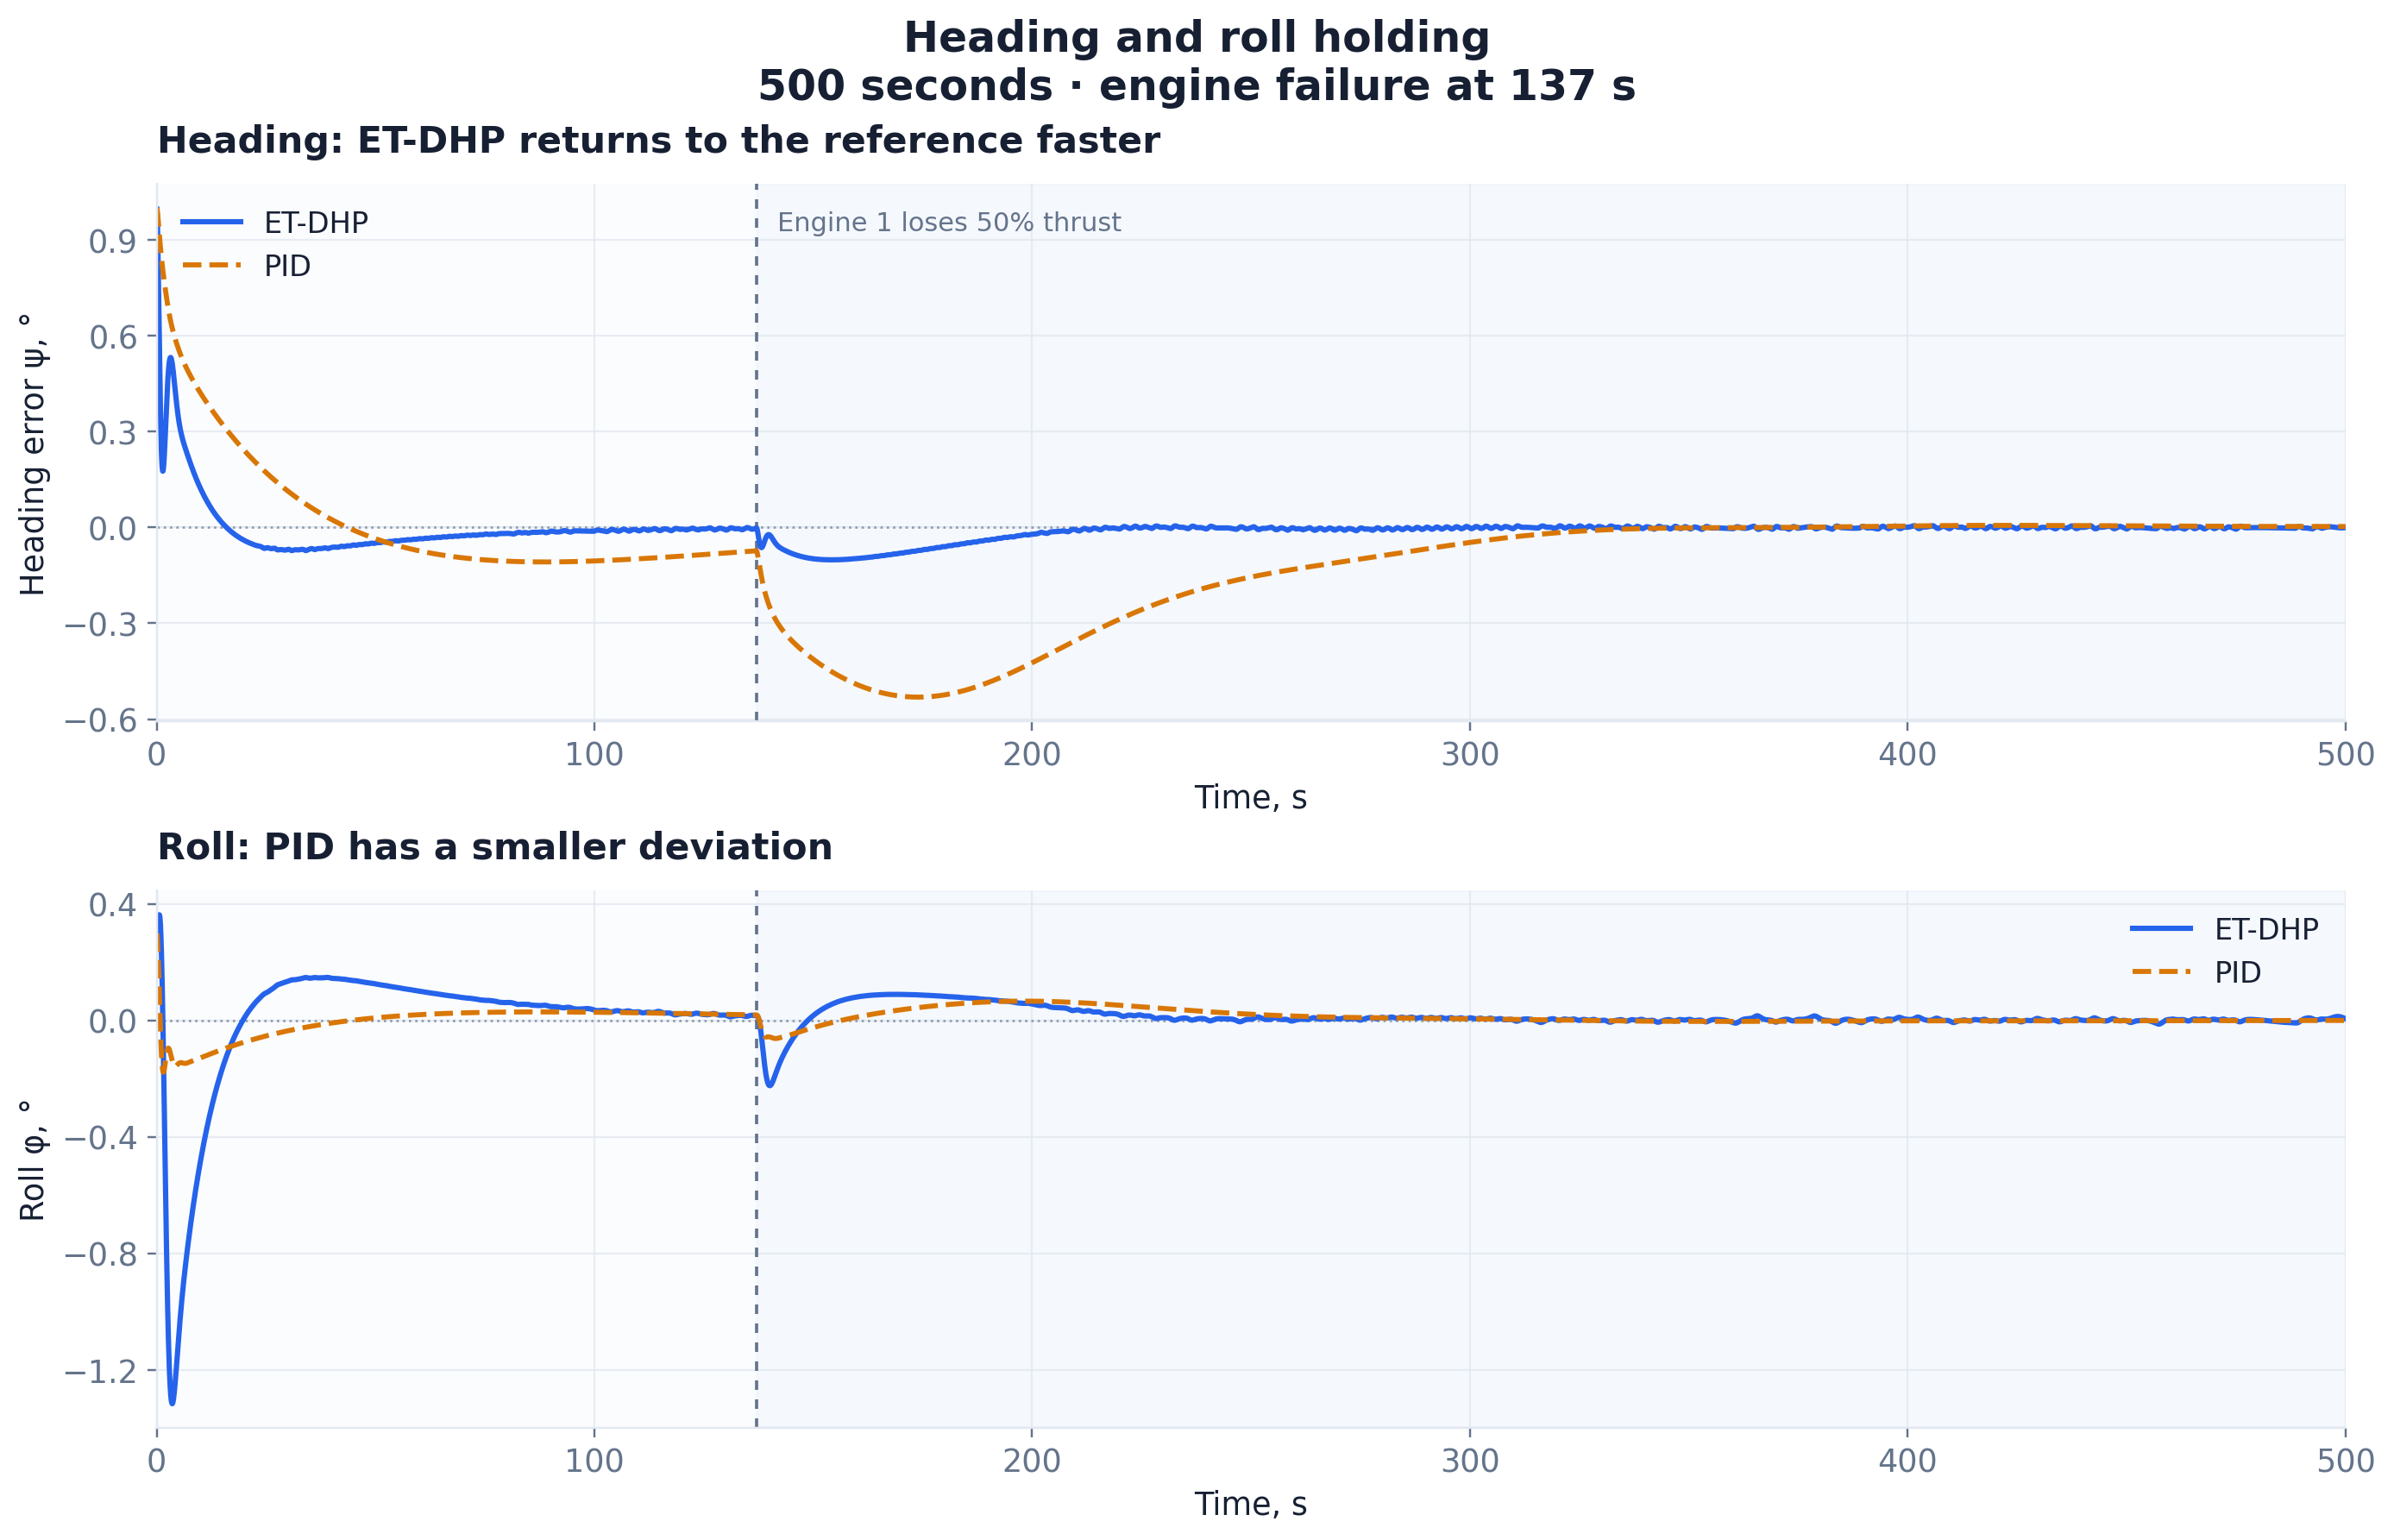

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8), constrained_layout=True)
heading(fig, 'Heading and roll holding', f'{duration:g} seconds · engine failure at {fault_time:g} s')
for ax, field, label, title in zip(axes, ['psi_deg', 'phi_deg'], ['Heading error ψ, °', 'Roll φ, °'], ['Heading: ET-DHP returns to the reference faster', 'Roll: PID has a smaller deviation']):
    pair(ax, field)
    decorate(ax, label)
    ax.set_title(title, loc='left', pad=12)
axes[0].annotate('Engine 1 loses 50% thrust', xy=(fault_time, .97), xycoords=('data', 'axes fraction'), xytext=(8, -4), textcoords='offset points', ha='left', va='top', fontsize=10, color=MUTED)
show_export(fig, '01_flight_overview')

## 2 · After failure

Left: the transient response. Right: the last 100 seconds on a separate vertical scale, showing small ET-DHP residual oscillations without smoothing.

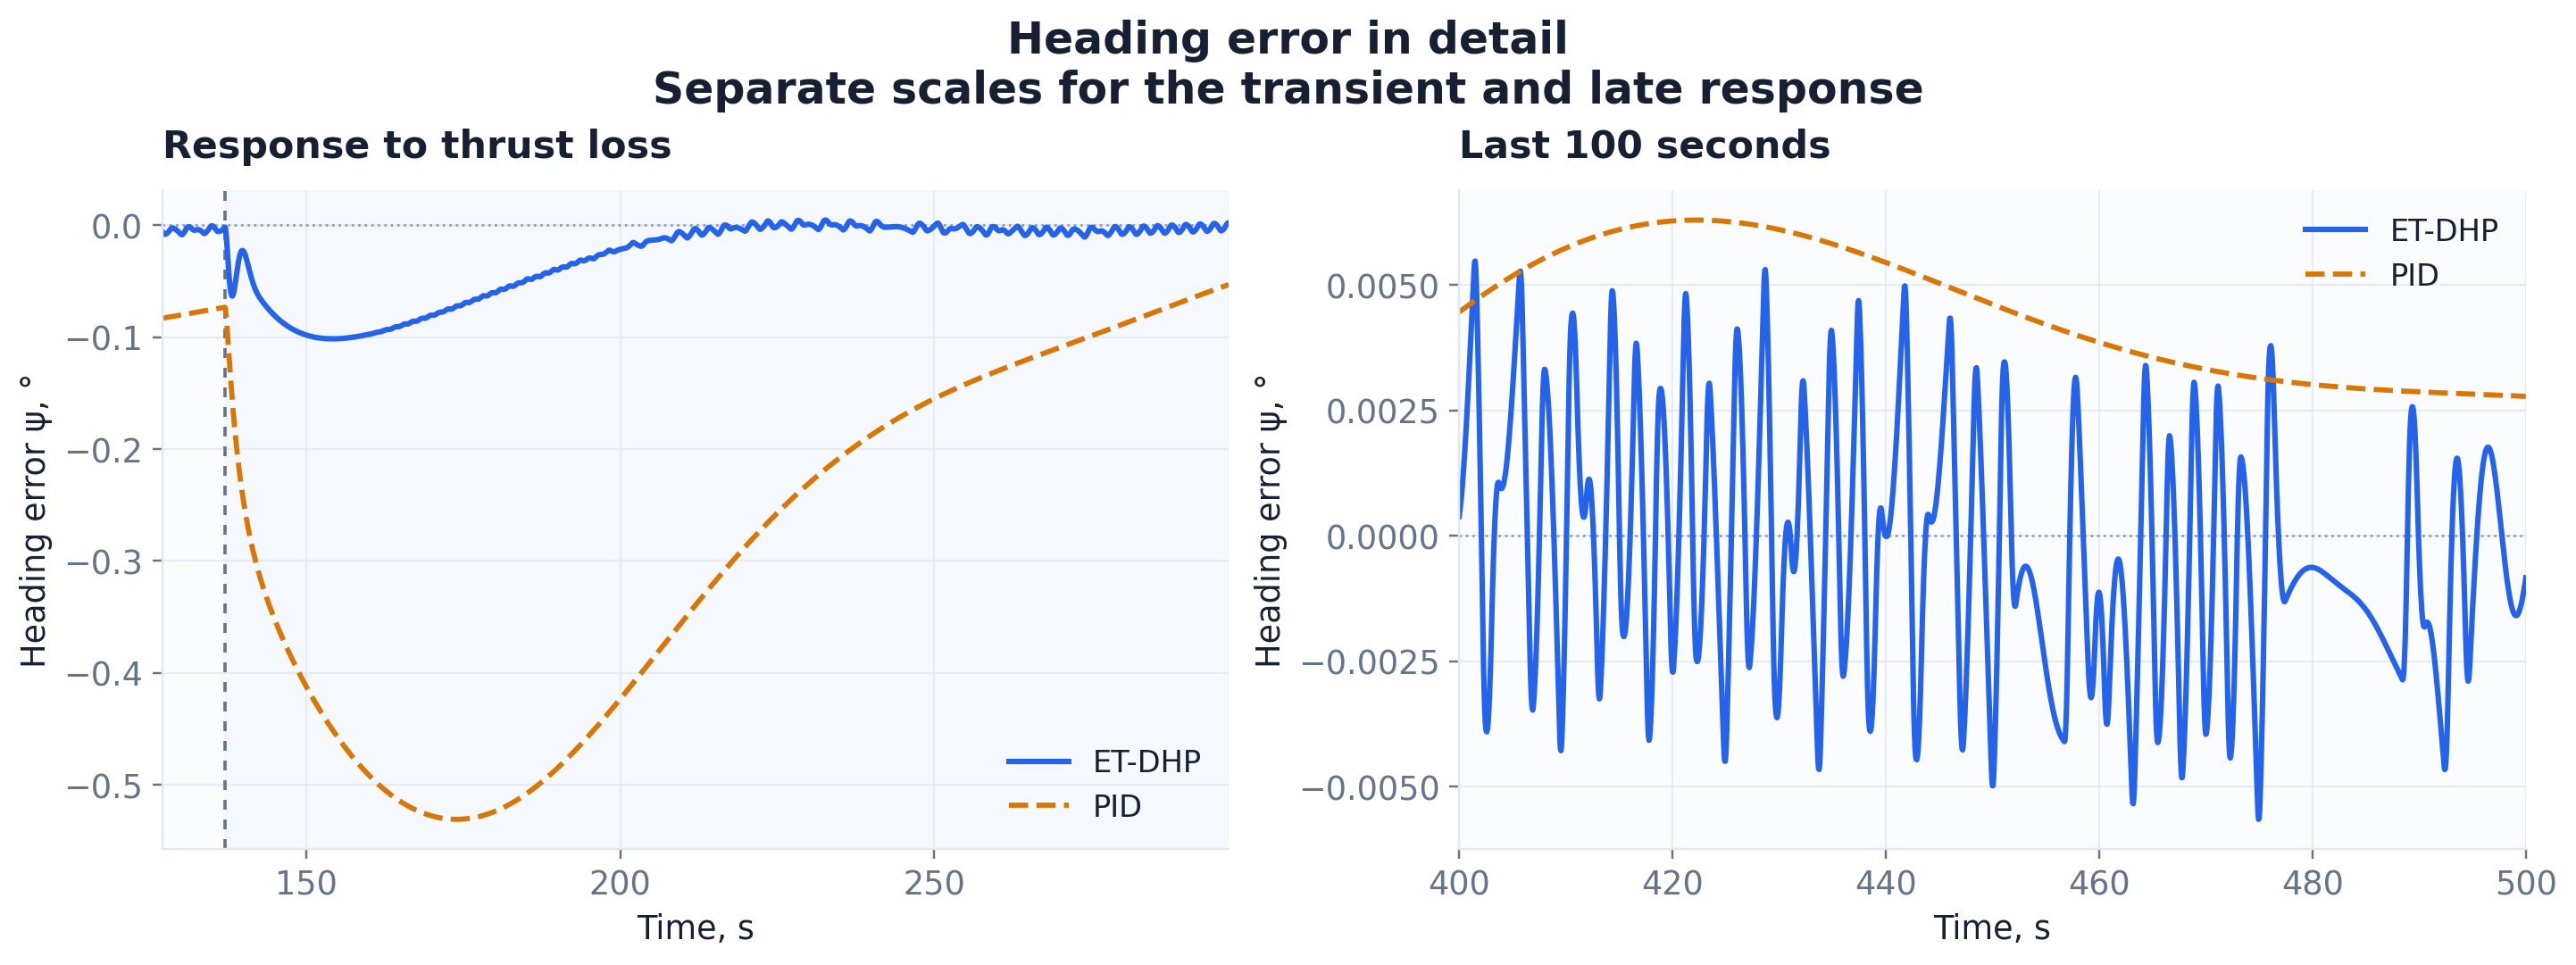

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
heading(fig, 'Heading error in detail', 'Separate scales for the transient and late response')
windows = [(max(0, fault_time-10), min(duration, fault_time+160)), (max(fault_time, duration-100), duration)]
for ax, window, title in zip(axes, windows, ['Response to thrust loss', 'Last 100 seconds']):
    pair(ax, 'psi_deg', window=window)
    decorate(ax, 'Heading error ψ, °', window=window)
    ax.set_title(title, loc='left', pad=12)
    ax.ticklabel_format(axis='y', style='plain', useOffset=False)
show_export(fig, '02_heading_detail')

## 3 · Numbers behind the plots

**RMSE** means root mean square error; lower is more accurate. The smaller value in each row is highlighted. These metrics apply to the specific controller settings used here.

In [5]:
specs = [
    ('Heading after failure', 'after_fault', 'heading_deg', 'rmse', '°'),
    ('Peak heading error after failure', 'after_fault', 'heading_deg', 'peak_abs', '°'),
    ('Heading over the last 100 s', 'last_100_s', 'heading_deg', 'rmse', '°'),
    ('Roll after failure', 'after_fault', 'roll_deg', 'rmse', '°'),
    ('Roll over the last 100 s', 'last_100_s', 'roll_deg', 'rmse', '°'),
    ('Speed after failure', 'after_fault', 'speed_ft_s', 'rmse', 'm/s'),
    ('Altitude after failure', 'after_fault', 'height_ft', 'rmse', 'm'),
]
rows = ['| Metric | ET-DHP | PID | Unit |', '|:---|---:|---:|:---|']
for label, window, field, statistic, unit in specs:
    factor = .3048 if unit in ('m', 'm/s') else 1
    a, b = [factor * value[window][field][statistic] for value in (m, p)]
    left, right = f'{a:.5f}', f'{b:.5f}'
    if a < b: left = '**' + left + '**'
    elif b < a: right = '**' + right + '**'
    rows.append(f'| {label} | {left} | {right} | {unit} |')
display(Markdown('\n'.join(rows)))

| Metric | ET-DHP | PID | Unit |
|:---|---:|---:|:---|
| Heading after failure | **0.03045** | 0.22265 | ° |
| Peak heading error after failure | **0.10161** | 0.53110 | ° |
| Heading over the last 100 s | **0.00242** | 0.00467 | ° |
| Roll after failure | 0.03708 | **0.02644** | ° |
| Roll over the last 100 s | 0.00441 | **0.00157** | ° |
| Speed after failure | **0.29350** | 0.29364 | m/s |
| Altitude after failure | 1.61735 | **1.61672** | m |

## 4 · Speed and altitude

Both lateral controllers share the same speed/altitude controller. The curves nearly overlap. Errors are shown in **metres and metres per second**; raw model data are saved in ft and ft/s.

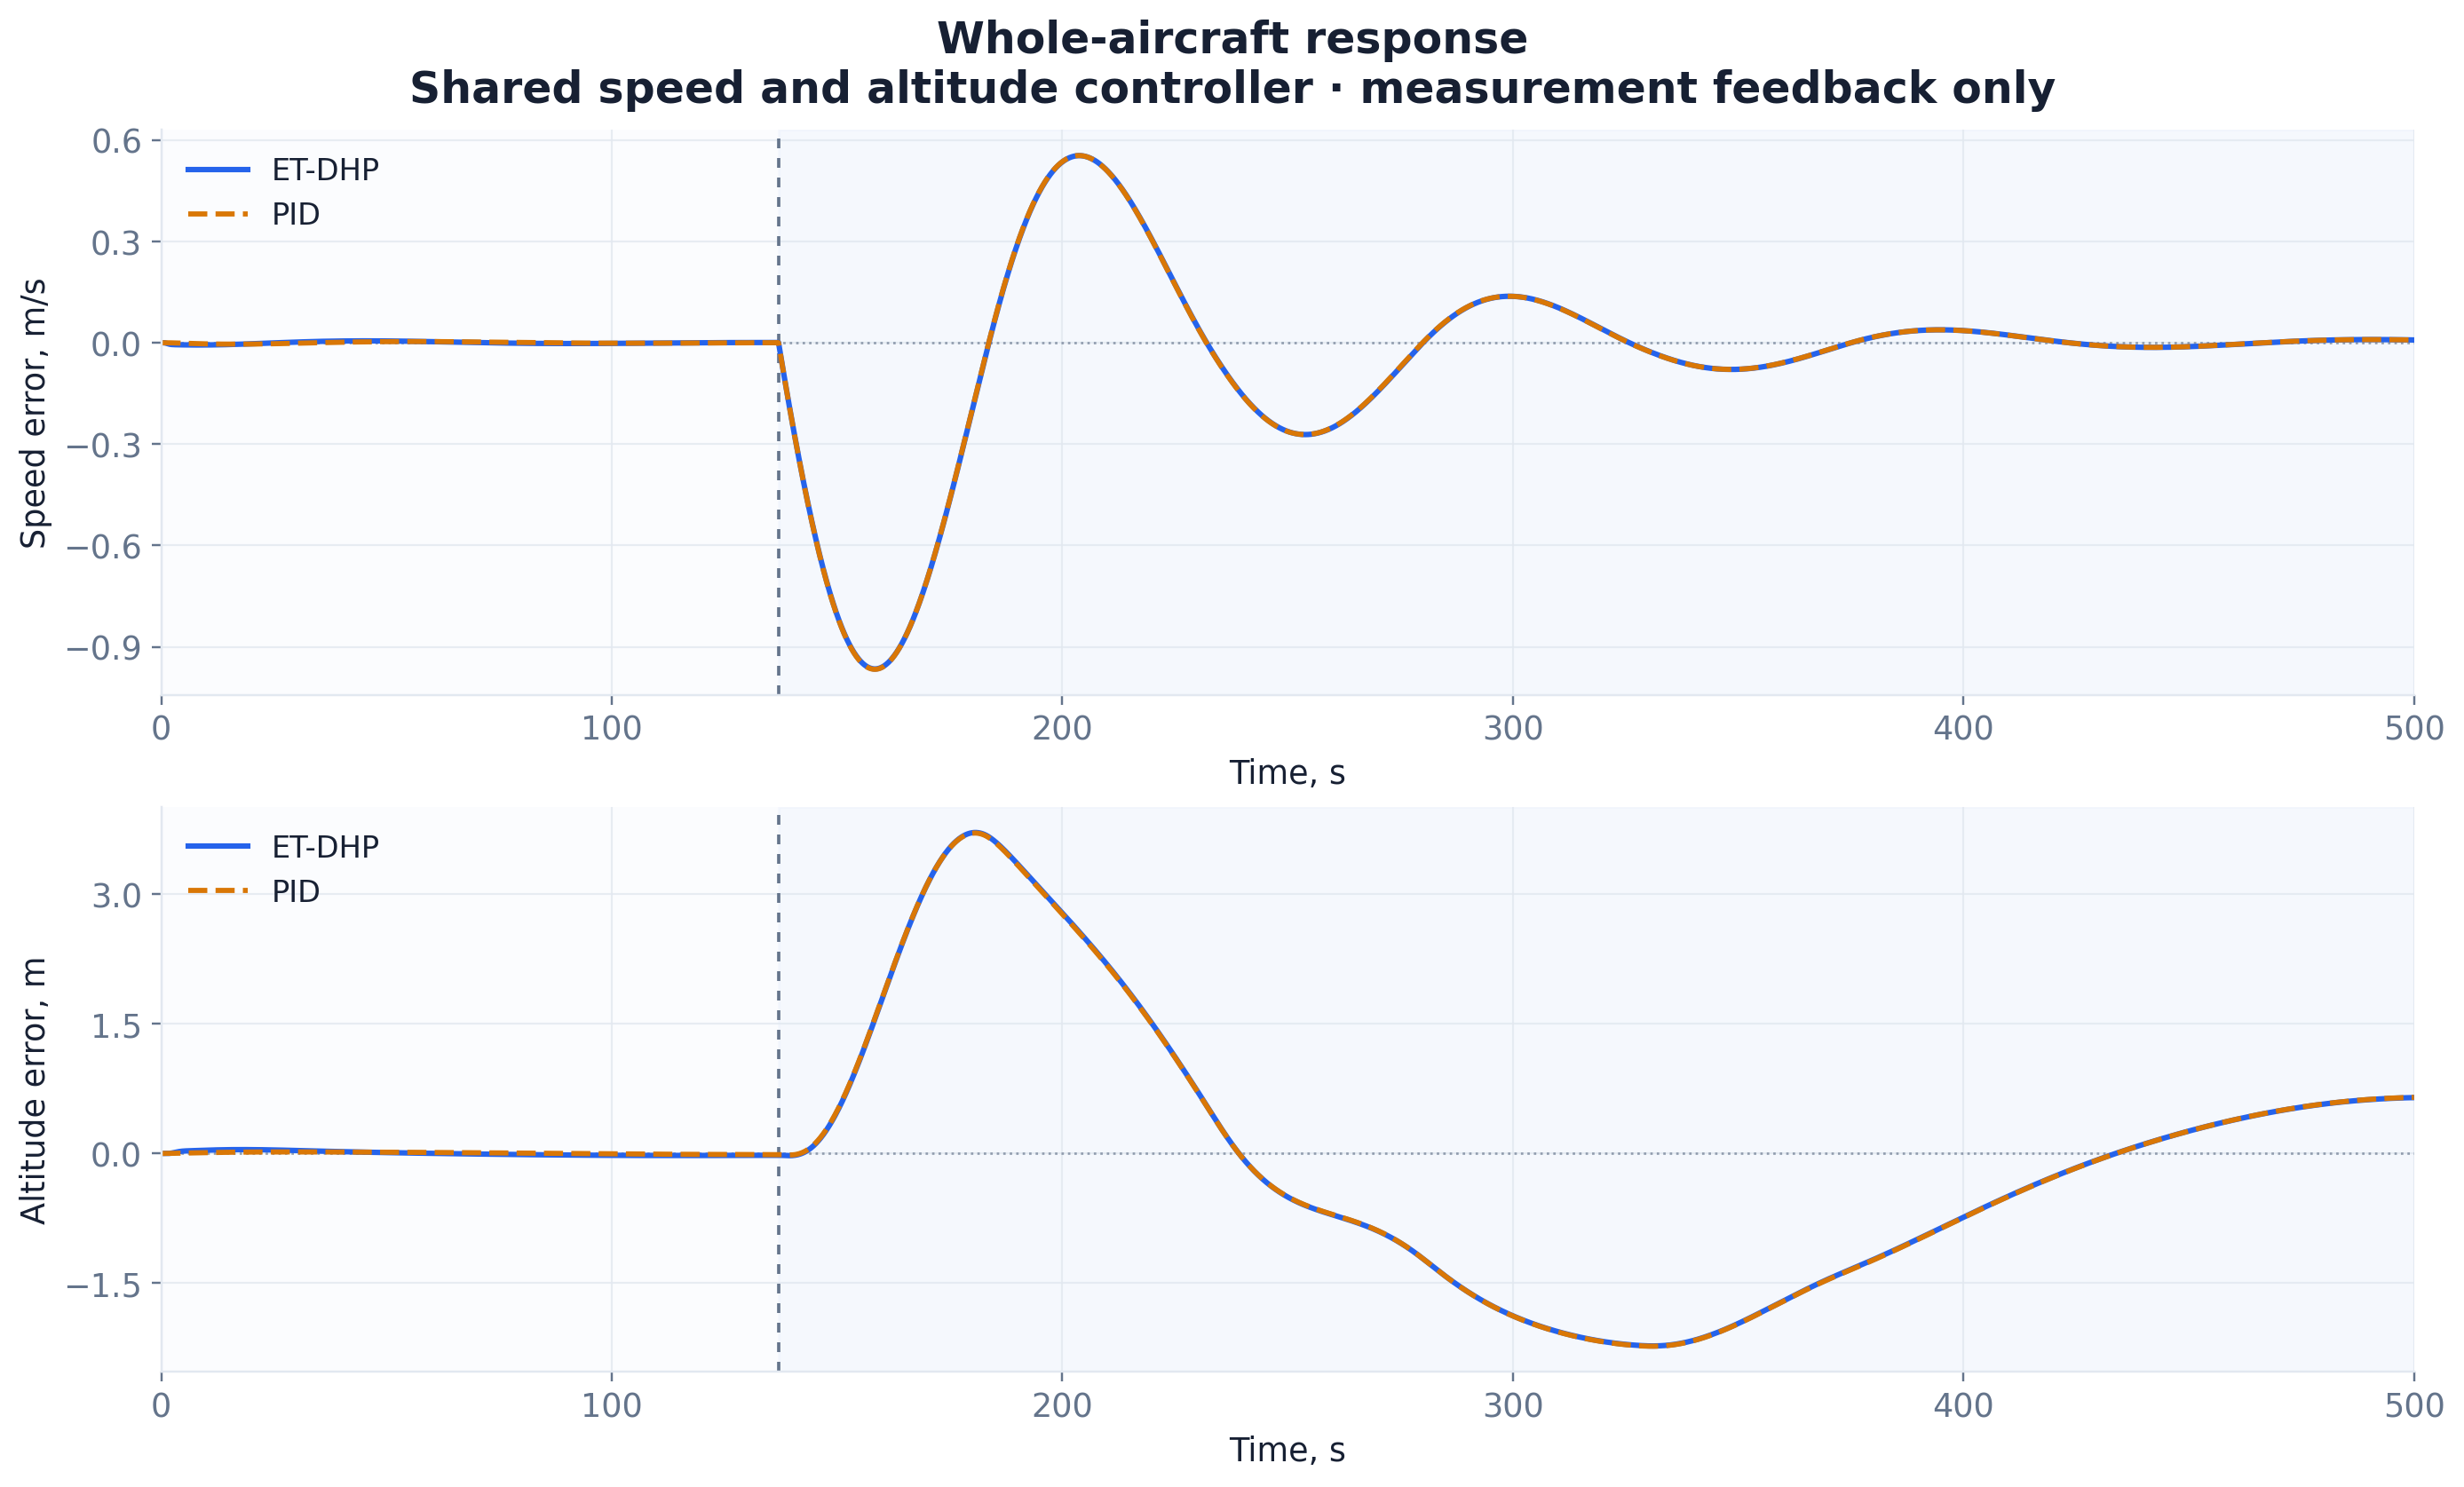

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 7.5), constrained_layout=True)
heading(fig, 'Whole-aircraft response', 'Shared speed and altitude controller · measurement feedback only')
for ax, field, label in zip(axes, ['speed_error_ft_s', 'height_error_ft'], ['Speed error, m/s', 'Altitude error, m']):
    pair(ax, field, scale=.3048)
    decorate(ax, label)
show_export(fig, '03_speed_altitude')

## 5 · Control commands

Ailerons and rudder have identical **±8°** limits for both controllers. These are surface commands; actuator dynamics are not included in this model.

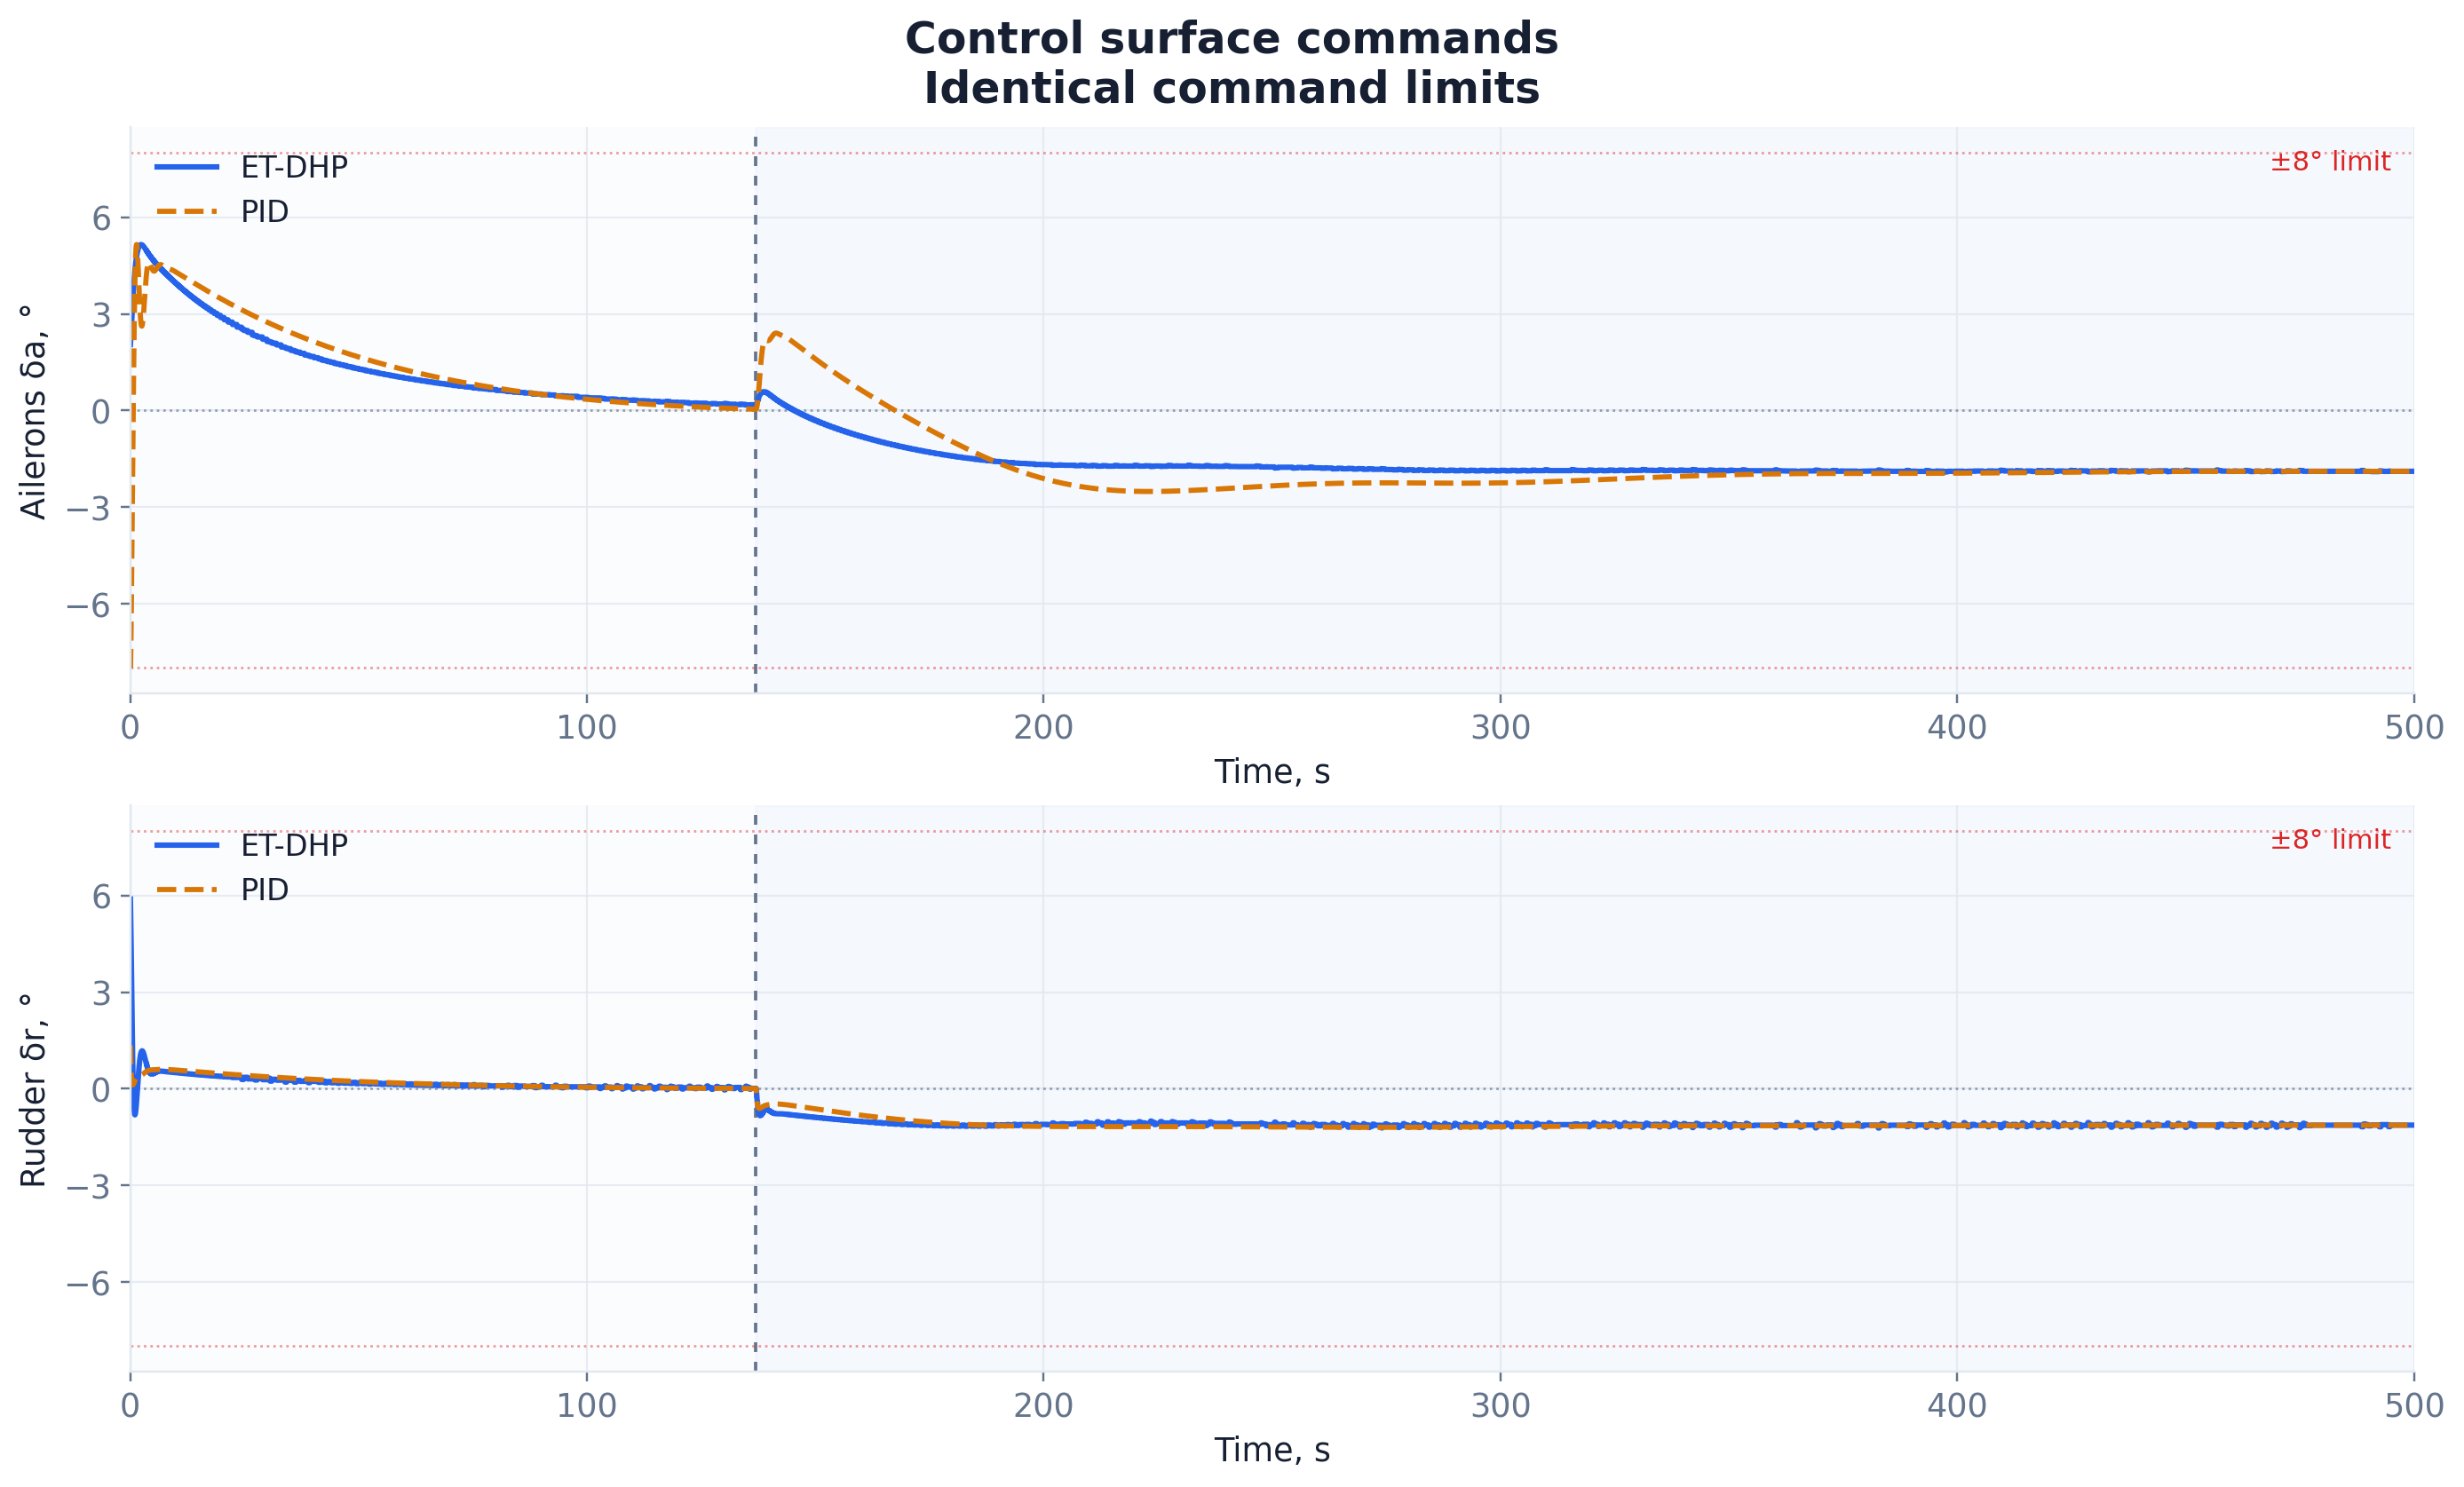

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 7.5), constrained_layout=True)
heading(fig, 'Control surface commands', 'Identical command limits')
for ax, field, label in zip(axes, ['aileron_deg', 'rudder_deg'], ['Ailerons δa, °', 'Rudder δr, °']):
    pair(ax, field)
    decorate(ax, label)
    ax.set_ylim(-8.8, 8.8)
    for limit in (-8, 8): ax.axhline(limit, color=RED, alpha=.45, lw=.9, ls=':')
    ax.text(.99, .96, '±8° limit', transform=ax.transAxes, ha='right', va='top', fontsize=10, color=RED)
show_export(fig, '04_control_commands')

## 6 · Learning continues after failure

ET-DHP updates its control and weights when the state trigger fires. The latest command is held between events. The right panel shows weight-change norms relative to the start of the episode. The nominal model stays fixed from the beginning; **the actor and critic continue learning after failure**.

The trigger count describes update frequency, not a computational advantage over PID.

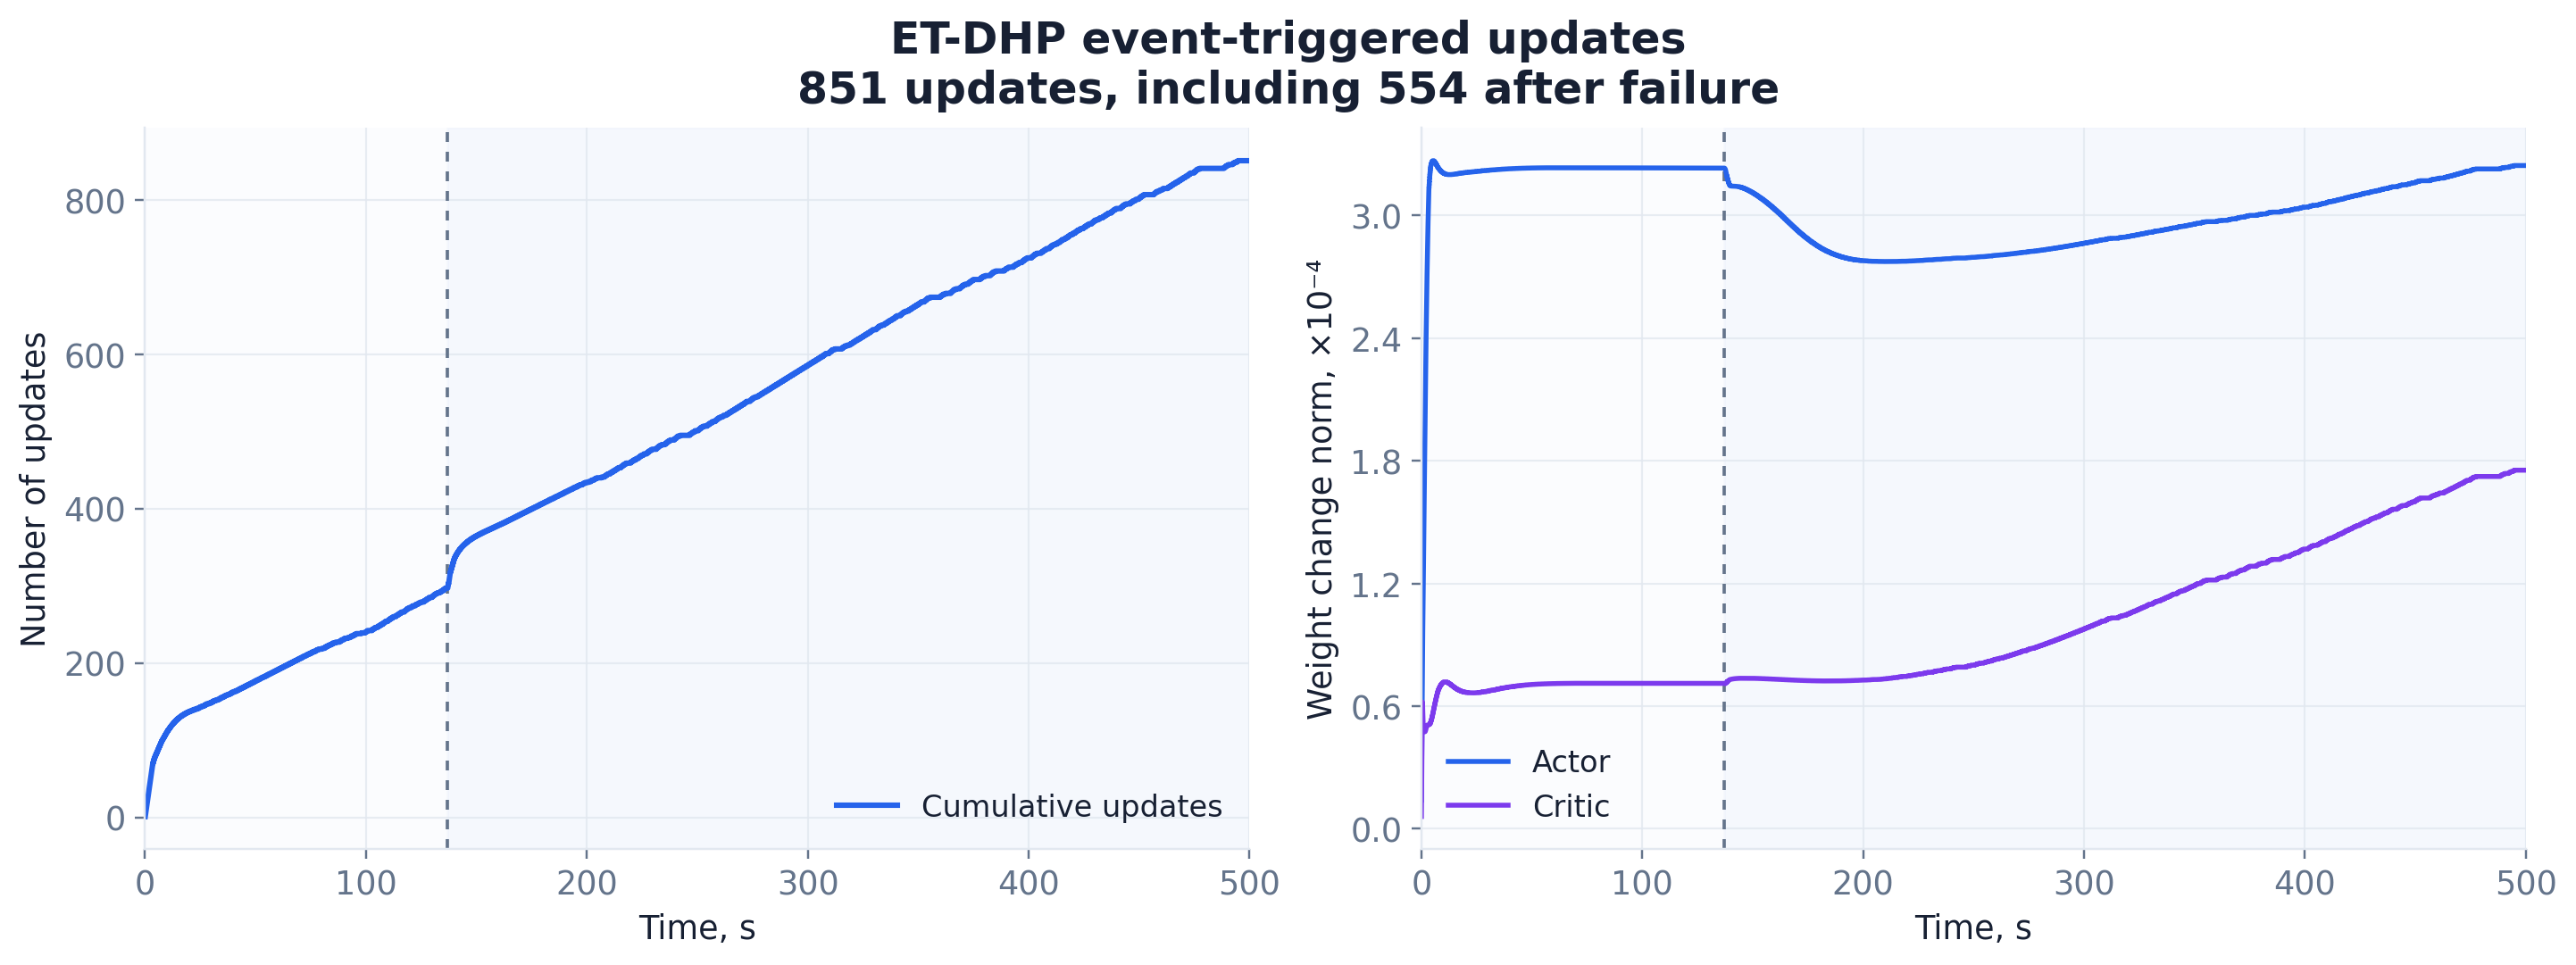

Weight changes **after failure**: actor — `0.0001050`, critic — `0.0001519`. Their contribution was not isolated from LQR initialization and integral feedback.

In [8]:
x = traces['fault_etdhp']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
run = report['runs']['fault_etdhp']
heading(fig, 'ET-DHP event-triggered updates', f"{run['triggers']} updates, including {run['triggers_after_event']} after failure")
axes[0].plot(x[:,0], np.cumsum(x[:,column['triggered']]), color=BLUE, lw=2, label='Cumulative updates')
decorate(axes[0], 'Number of updates', zero=False)
axes[1].plot(x[:,0], x[:,column['actor_change']]*1e4, color=BLUE, lw=1.8, label='Actor')
axes[1].plot(x[:,0], x[:,column['critic_change']]*1e4, color='#7C3AED', lw=1.8, label='Critic')
decorate(axes[1], 'Weight change norm, ×10⁻⁴', zero=False)
show_export(fig, '05_learning_activity')
display(Markdown(f"Weight changes **after failure**: actor — `{run['parameter_change_after_event'][0]:.7f}`, critic — `{run['parameter_change_after_event'][1]:.7f}`. Their contribution was not isolated from LQR initialization and integral feedback."))

## 7 · A variant that performs worse

The red curve shows a separately tuned ET-DHP with additional online plant-model learning. All three networks learn in this variant. Error increases toward the end of the episode; completing a simulation does not imply successful heading holding.

The variants use different fitted learning rates, so this comparison **does not isolate the effect of the `online_model_fit` switch alone**.

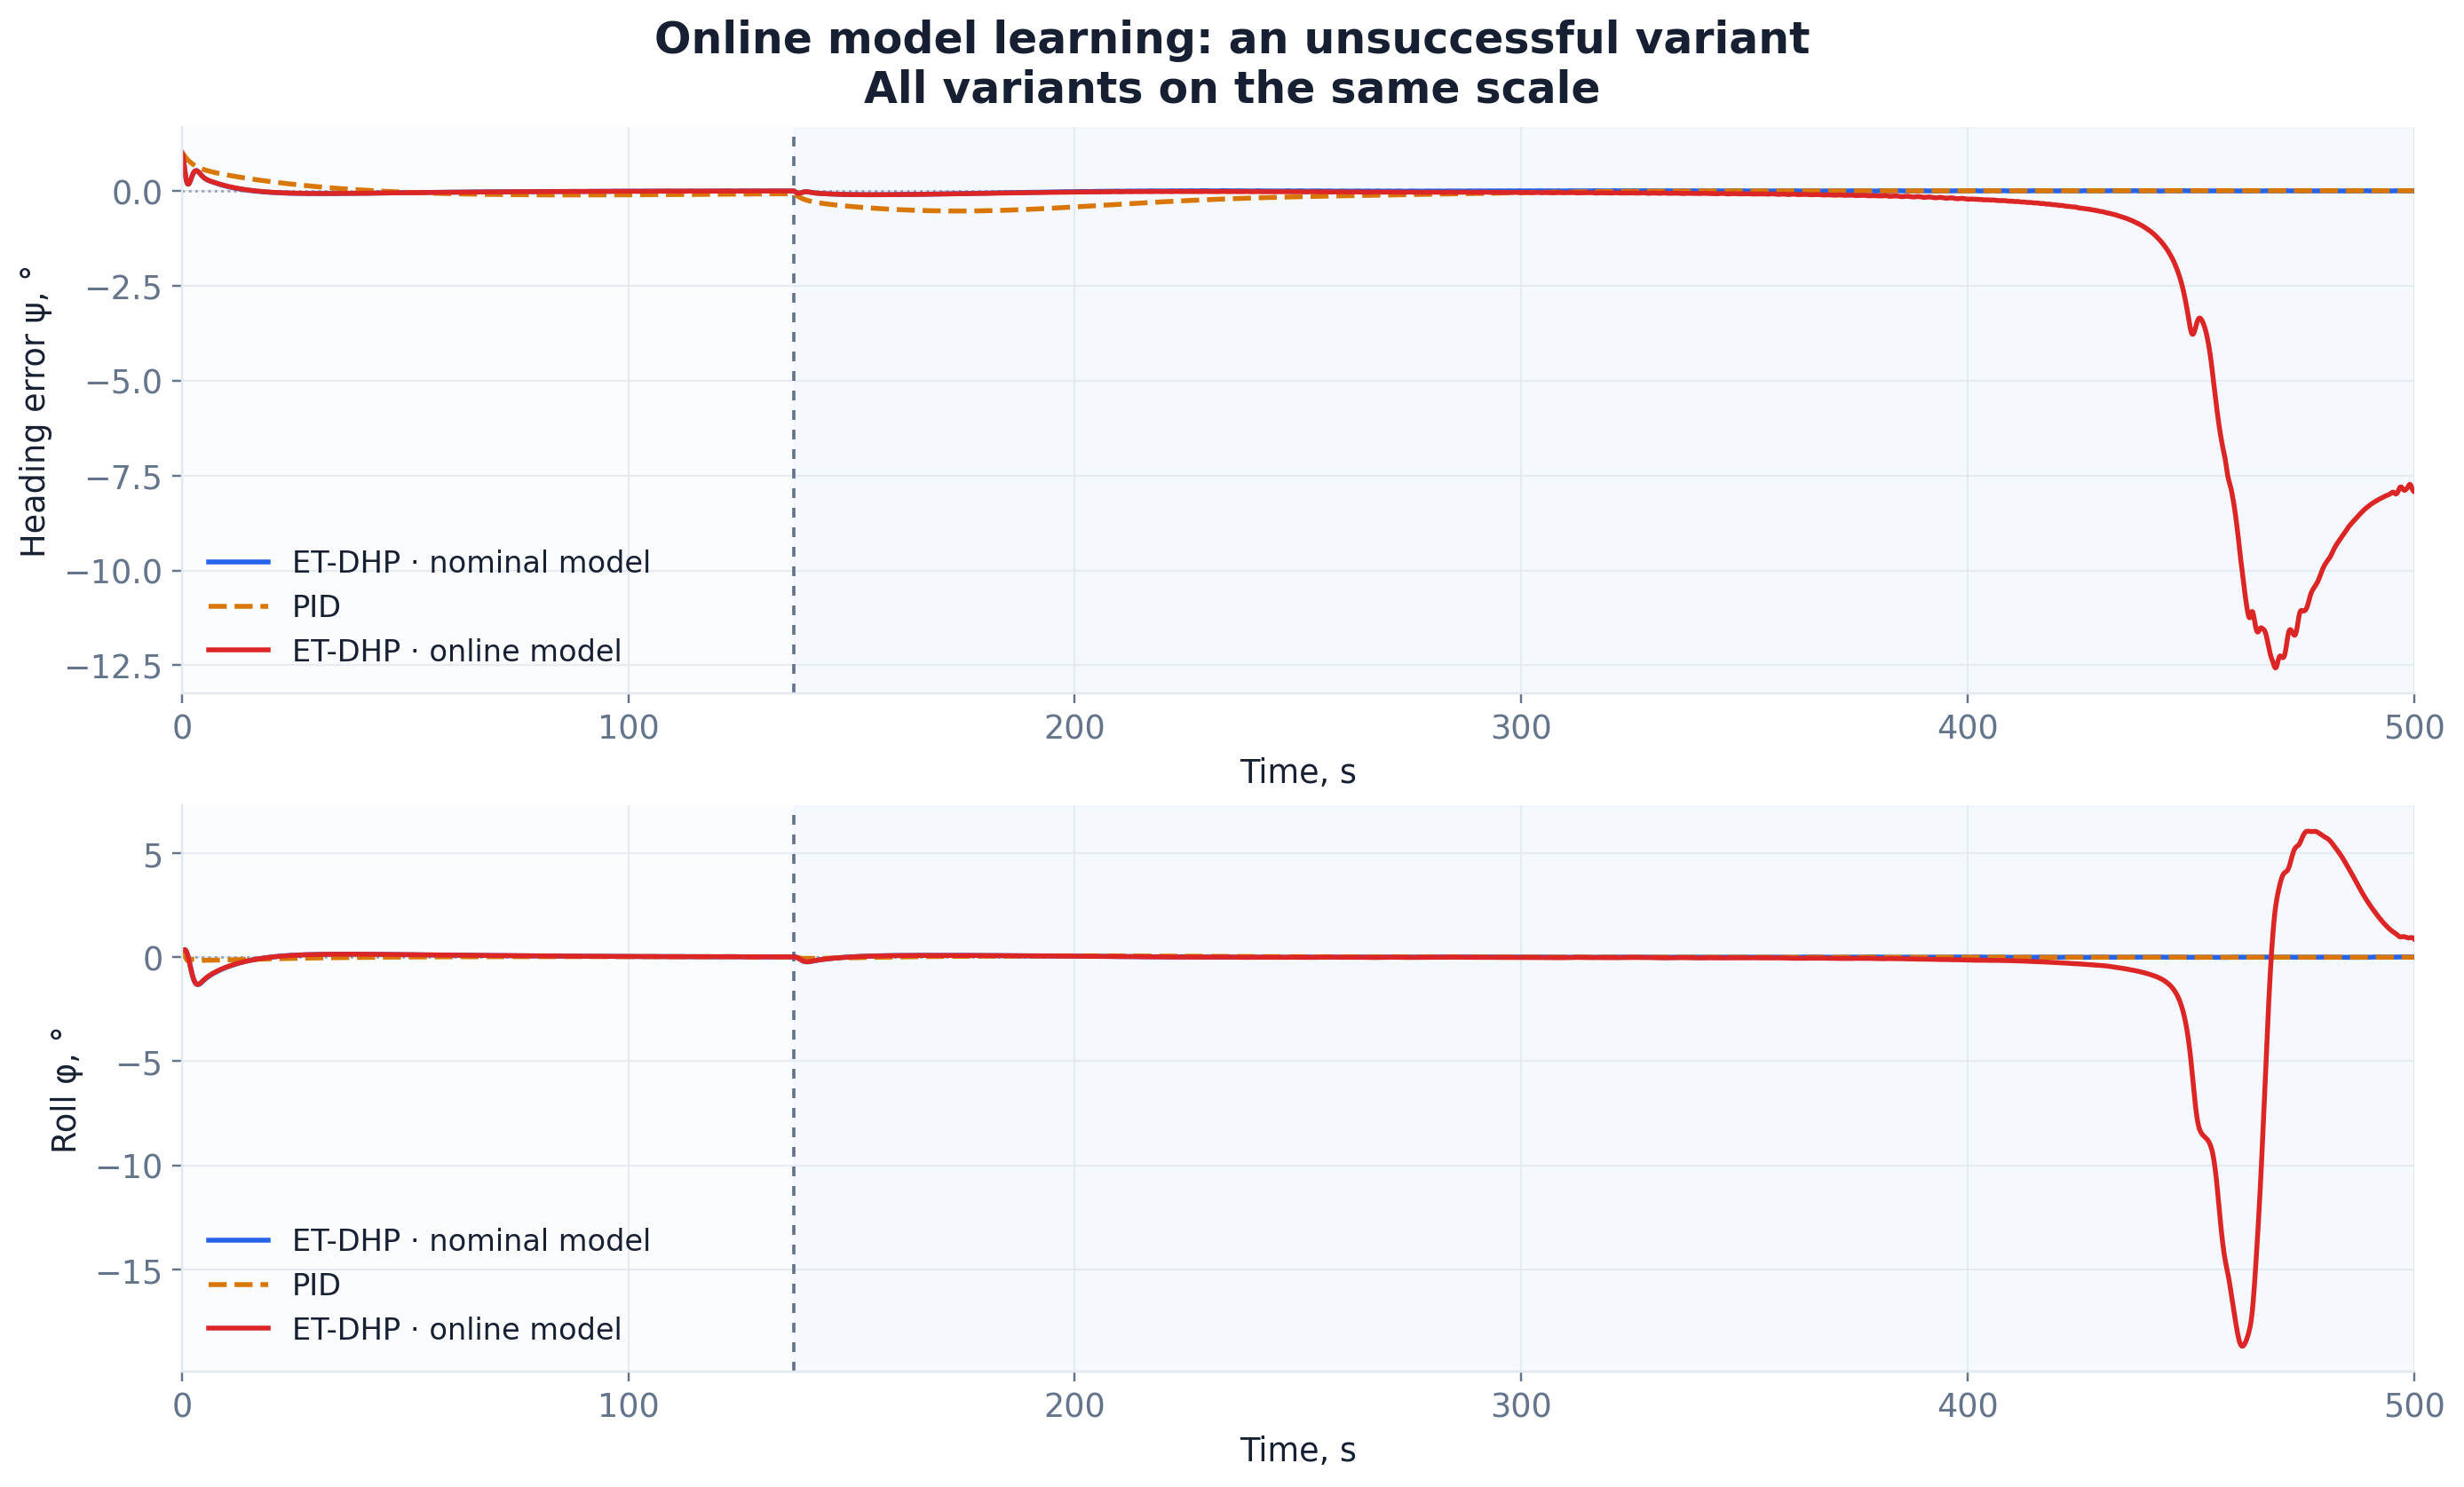

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 7.5), constrained_layout=True)
heading(fig, 'Online model learning: an unsuccessful variant', 'All variants on the same scale')
for key, label, color, ls in [('fault_etdhp', 'ET-DHP · nominal model', BLUE, '-'), ('fault_pid', 'PID', ORANGE, '--'), ('fault_etdhp_online_model', 'ET-DHP · online model', RED, '-')]:
    x = traces[key]
    axes[0].plot(x[:,0], x[:,column['psi_deg']], color=color, ls=ls, lw=1.8, label=label)
    axes[1].plot(x[:,0], x[:,column['phi_deg']], color=color, ls=ls, lw=1.8, label=label)
decorate(axes[0], 'Heading error ψ, °')
decorate(axes[1], 'Roll φ, °')
show_export(fig, '06_online_model_variant')

## Conclusions and limits

- **ET-DHP holds heading more accurately; PID holds roll more accurately.** PID is also more accurate late in the healthy-aircraft episode.
- ET-DHP uses LQR initialization on the healthy model. It is not trained from scratch, and the improvement cannot be attributed solely to online adaptation.
- PID was fitted on the healthy aircraft only; the search exhausted its computational budget, with no claim of global optimality.
- The nonlinear 6-DoF model approximates aerodynamics using local derivatives. Servo dynamics, engine spool dynamics, wind, and measurement noise are absent.
- Full protocol, other failure times, complete engine failure, and integration-step checks: `reports/etdhp-b747-pid-validation.md`.

Figures are exported to PNG and SVG; all six pages are also combined into a PDF. Set `RERUN_SIMULATION = True` in the first code cell to rerun the simulation.

In [10]:
pdf_path = figure_dir / 'etdhp_vs_pid_b747_figures.pdf'
with PdfPages(pdf_path, metadata={'Title': 'ET-DHP vs PID — nonlinear B747', 'Author': 'TensorAeroSpace'}) as pdf:
    for _, figure in exports:
        pdf.savefig(figure, facecolor='white', bbox_inches='tight')
print(f'Done: {len(exports)} figures in PNG/SVG and PDF.')
print('Directory:', figure_dir.relative_to(repo))

Done: 6 figures in PNG/SVG and PDF.
Directory: outputs/b747-etdhp-vs-pid/presentation
